# lib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tools as tls
import re

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sentence_transformers import SentenceTransformer   
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn import metrics

from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from keras.layers import Input, Dense, Dropout
from keras.models import Sequential

/home/bright381/OpenClassrooms/Projet_8/SBERT-TFIDF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1787323902.026978  923450 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787323902.051293  923450 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787323902.613887  923450 port.cc:153] oneDNN custom operations are on. You may

# exploration

In [2]:
data = pd.read_csv("data/flipkart_com-ecommerce_sample_1050.csv")

In [3]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [4]:
data.nunique()

uniq_id                    1050
crawl_timestamp             149
product_url                1050
product_name               1050
product_category_tree       642
pid                        1050
retail_price                354
discounted_price            424
image                      1050
is_FK_Advantage_product       2
description                1050
product_rating               27
overall_rating               27
brand                       490
product_specifications      984
dtype: int64

In [5]:
data.dtypes

uniq_id                        str
crawl_timestamp                str
product_url                    str
product_name                   str
product_category_tree          str
pid                            str
retail_price               float64
discounted_price           float64
image                          str
is_FK_Advantage_product       bool
description                    str
product_rating                 str
overall_rating                 str
brand                          str
product_specifications         str
dtype: object

In [6]:
data['product_specifications']

0       {"product_specification"=>[{"key"=>"Brand", "v...
1       {"product_specification"=>[{"key"=>"Machine Wa...
2       {"product_specification"=>[{"key"=>"Material",...
3       {"product_specification"=>[{"key"=>"Brand", "v...
4       {"product_specification"=>[{"key"=>"Machine Wa...
                              ...                        
1045    {"product_specification"=>[{"key"=>"Number of ...
1046    {"product_specification"=>[{"key"=>"Number of ...
1047    {"product_specification"=>[{"key"=>"Number of ...
1048    {"product_specification"=>[{"key"=>"Number of ...
1049    {"product_specification"=>[{"key"=>"Sales Pack...
Name: product_specifications, Length: 1050, dtype: str

In [7]:
data['product_category_tree']

0       ["Home Furnishing >> Curtains & Accessories >>...
1       ["Baby Care >> Baby Bath & Skin >> Baby Bath T...
2       ["Baby Care >> Baby Bath & Skin >> Baby Bath T...
3       ["Home Furnishing >> Bed Linen >> Bedsheets >>...
4       ["Home Furnishing >> Bed Linen >> Bedsheets >>...
                              ...                        
1045    ["Baby Care >> Baby & Kids Gifts >> Stickers >...
1046    ["Baby Care >> Baby & Kids Gifts >> Stickers >...
1047    ["Baby Care >> Baby & Kids Gifts >> Stickers >...
1048    ["Baby Care >> Baby & Kids Gifts >> Stickers >...
1049    ["Baby Care >> Baby & Kids Gifts >> Stickers >...
Name: product_category_tree, Length: 1050, dtype: str

## missing values

In [8]:
data[data.isna().any(axis=1)]

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
5,893aa5ed55f7cff2eccea7758d7a86bd,2015-12-04 07:25:36 +0000,http://www.flipkart.com/maserati-time-r8851116...,Maserati Time R8851116001 Analog Watch - For ...,"[""Watches >> Wrist Watches >> Maserati Time Wr...",WATEAYAHJ8CUCAYM,24400.0,24400.0,893aa5ed55f7cff2eccea7758d7a86bd.jpg,False,Maserati Time R8851116001 Analog Watch - For ...,No rating available,No rating available,NaN,"{""product_specification""=>[{""key""=>""Chronograp..."
6,f355cc1ccb08bd0d283ed979b7ee7515,2015-12-04 07:25:36 +0000,http://www.flipkart.com/camerii-wm64-elegance-...,"Camerii WM64 Elegance Analog Watch - For Men,...","[""Watches >> Wrist Watches >> Camerii Wrist Wa...",WATE6Y6D2MZHWGBZ,1099.0,449.0,f355cc1ccb08bd0d283ed979b7ee7515.jpg,False,"Camerii WM64 Elegance Analog Watch - For Men,...",5,5,NaN,"{""product_specification""=>[{""key""=>""Chronograp..."
7,dd0e3470a7e6ed76fd69c2da27721041,2015-12-04 07:25:36 +0000,http://www.flipkart.com/t-star-uft-tsw-005-bk-...,T STAR UFT-TSW-005-BK-BR Analog Watch - For Boys,"[""Watches >> Wrist Watches >> T STAR Wrist Wat...",WATECFFVGFZPAD3D,999.0,399.0,dd0e3470a7e6ed76fd69c2da27721041.jpg,False,T STAR UFT-TSW-005-BK-BR Analog Watch - For B...,No rating available,No rating available,NaN,"{""product_specification""=>[{""key""=>""Chronograp..."
8,41384da51732c0b4df3de8f395714fbb,2015-12-04 07:25:36 +0000,http://www.flipkart.com/alfajr-wy16b-youth-dig...,"Alfajr WY16B Youth Digital Watch - For Men, Boys","[""Watches >> Wrist Watches >> Alfajr Wrist Wat...",WATECHFU4QGFQEJG,5495.0,4995.0,41384da51732c0b4df3de8f395714fbb.jpg,False,"Alfajr WY16B Youth Digital Watch - For Men, B...",No rating available,No rating available,NaN,"{""product_specification""=>[{""key""=>""Chronograp..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,7b1c5edc85bc7e31edf49ab70034bb3a,2016-01-01 13:15:34 +0000,http://www.flipkart.com/incolor-metalic-lipsti...,Incolor Metalic Lipstick N15 3.8 g,"[""Beauty and Personal Care >> Makeup >> Lips >...",LSKE36A69ZNY64DG,210.0,210.0,7b1c5edc85bc7e31edf49ab70034bb3a.jpg,False,Flipkart.com: Buy Incolor Metalic Lipstick N15...,3,3,NaN,"{""product_specification""=>[{""key""=>""Quantity"",..."
946,2cc24452688ed35dfbff566e22e53c95,2016-01-01 13:15:34 +0000,http://www.flipkart.com/organistick-silver-lab...,Organistick Silver Label Lipstick 10 g,"[""Beauty and Personal Care >> Makeup >> Lips >...",LSKE6FWHDDWY7J5T,149.0,149.0,2cc24452688ed35dfbff566e22e53c95.jpg,False,Flipkart.com: Buy Organistick Silver Label Lip...,No rating available,No rating available,NaN,"{""product_specification""=>[{""key""=>""Organic Ty..."
957,e488005c7fb68747d3458c7d73760bae,2016-02-24 04:24:17 +0000,http://www.flipkart.com/nutcase-multicolor-col...,Nutcase Multicolor Column Floor Lamp,"[""Home Decor & Festive Needs >> Decorative Lig...",FIOEFUXPJQYZKDXZ,3299.0,1299.0,e488005c7fb68747d3458c7d73760bae.jpg,False,Key Features of Nutcase Multicolor Column Floo...,No rating available,No rating available,Nutcase,NaN
985,edb97bd2433fd9de301c8a44344777bb,2016-01-04 03:25:23 +0000,http://www.flipkart.com/artist-haat-vanity-box...,Artist Haat Vanity Box Makeup and Jewellery Va...,"[""Beauty and Personal Care >> Makeup >> Vanity...",VANEE2FFWVZZQHJV,1800.0,1499.0,edb97bd2433fd9de301c8a44344777bb.jpg,False,Artist Haat Vanity Box Makeup and Jewellery Va...,No rating available,No rating available,NaN,"{""pr

In [9]:
data[data[['uniq_id', 'product_name', 'product_category_tree', 'description', 'image', 'product_specifications']].isna().any(axis=1)]

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
957,e488005c7fb68747d3458c7d73760bae,2016-02-24 04:24:17 +0000,http://www.flipkart.com/nutcase-multicolor-col...,Nutcase Multicolor Column Floor Lamp,"[""Home Decor & Festive Needs >> Decorative Lig...",FIOEFUXPJQYZKDXZ,3299.0,1299.0,e488005c7fb68747d3458c7d73760bae.jpg,False,Key Features of Nutcase Multicolor Column Floo...,No rating available,No rating available,Nutcase,NaN


In [10]:
data[data['description'].str.strip().eq('')]

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications


## descriptions

In [11]:
data['description'].str.len().min(), data['description'].str.len().max(), data['description'].str.len().mean()

(np.int64(109), np.int64(3490), np.float64(473.8209523809524))

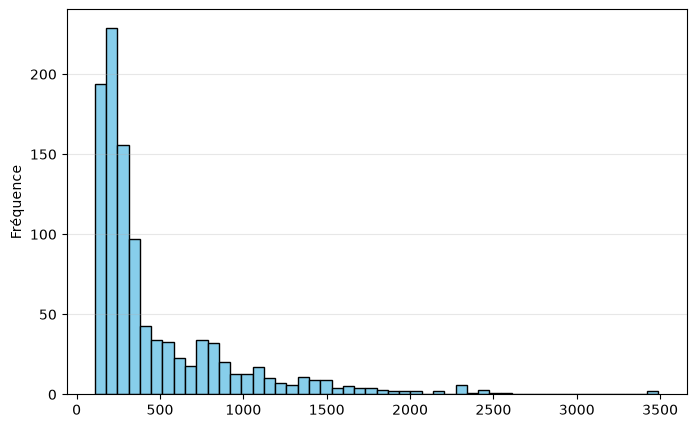

In [12]:
lengths = data['description'].str.len()

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black')

plt.ylabel("Fréquence")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [13]:
data['description']

0       Key Features of Elegance Polyester Multicolor ...
1       Specifications of Sathiyas Cotton Bath Towel (...
2       Key Features of Eurospa Cotton Terry Face Towe...
3       Key Features of SANTOSH ROYAL FASHION Cotton P...
4       Key Features of Jaipur Print Cotton Floral Kin...
                              ...                        
1045    Oren Empower Extra Large Self Adhesive Sticker...
1046    Wallmantra Large Vinyl Sticker Sticker (Pack o...
1047    Buy Uberlyfe Extra Large Pigmented Polyvinyl F...
1048    Buy Wallmantra Medium Vinyl Sticker Sticker fo...
1049    Buy Uberlyfe Large Vinyl Sticker for Rs.595 on...
Name: description, Length: 1050, dtype: str

### nombre de par mots

In [14]:
data['description'].str.split().str.len()

0       230
1        74
2       215
3       145
4       214
       ... 
1045    419
1046    287
1047     37
1048     31
1049     29
Name: description, Length: 1050, dtype: int64

In [15]:
data['description'].str.split(pat=' ').apply(len).min(), data['description'].str.split(pat=' ').apply(len).max(), data['description'].str.split(pat=' ').apply(len).mean()

(np.int64(18), np.int64(589), np.float64(80.32190476190476))

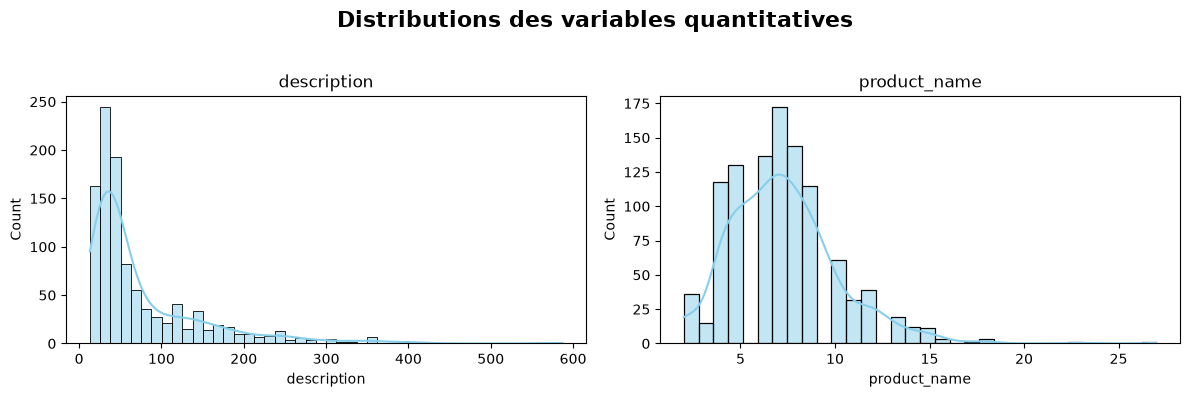

In [16]:
tls.plot_quantitative(data[['description', 'product_name']].apply(lambda col: col.str.split().str.len()))


# Preparation extraction

In [17]:
descriptions = data[['uniq_id', 'product_name', 'product_category_tree', 'description']].copy()

In [18]:
descriptions['name_description'] = descriptions['product_name'] + ' ' + descriptions['description'] 
unprocessed=pd.DataFrame()
unprocessed = descriptions.copy()

In [19]:
def to_string(df, columns: list):
    for column in columns:
        df[column]=df[column].astype(str)
    return df

def preprocess_text(text: str):
    text=text.lower()
    text=re.sub(r'\s+', ' ', text)
    text=re.sub("\n", ' ', text)
    return text

In [20]:
to_string(descriptions, columns=['description', 'product_name', 'name_description', 'product_category_tree'])

,uniq_id,product_name,product_category_tree,description,name_description
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",Key Features of Elegance Polyester Multicolor ...,Elegance Polyester Multicolor Abstract Eyelet ...
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Specifications of Sathiyas Cotton Bath Towel (...,Sathiyas Cotton Bath Towel Specifications of S...
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Key Features of Eurospa Cotton Terry Face Towe...,Eurospa Cotton Terry Face Towel Set Key Featur...
3,d4684dcdc759dd9cdf41504698d737d8,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Key Features of SANTOSH ROYAL FASHION Cotton P...,SANTOSH ROYAL FASHION Cotton Printed King size...
4,6325b6870c54cd47be6ebfbffa620ec7,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Key Features of Jaipur Print Cotton Floral Kin...,Jaipur Print Cotton Floral King sized Double B...
...,...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc,Oren Empower Extra Large Self Adhesive Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Oren Empower Extra Large Self Adhesive Sticker...,Oren Empower Extra Large Self Adhesive Sticker...
1046,fd6cbcc22efb6b761bd564c28928483c,Wallmantra Large Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Wallmantra Large Vinyl Sticker Sticker (Pack o...,Wallmantra Large Vinyl Sticker Sticker Wallman...
1047,5912e037d12774bb73a2048f35a00009,Uberlyfe Extra Large Pigmented Polyvinyl Films...,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,Uberlyfe Extra Large Pigmented Polyvinyl Films...
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,Wallmantra Medium Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Buy Wallmantra Medium Vinyl Sticker Sticker fo...,Wallmantra Medium Vinyl Sticker Sticker Buy Wa...


In [21]:
descriptions['name_description']=descriptions['name_description'].apply(preprocess_text)

## Main cat

In [22]:
descriptions['product_category_tree'].apply(lambda x: x.replace("[", "").replace('\"', "").replace("]", "").split(' >> ')[0])

0       Home Furnishing
1             Baby Care
2             Baby Care
3       Home Furnishing
4       Home Furnishing
             ...       
1045          Baby Care
1046          Baby Care
1047          Baby Care
1048          Baby Care
1049          Baby Care
Name: product_category_tree, Length: 1050, dtype: str

In [23]:
descriptions['main_cat'] = descriptions['product_category_tree'].apply(lambda x: x.replace("[", "").replace('\"', "").replace("]", "").split(' >> ')[0])

In [24]:
descriptions['main_cat'].value_counts()

main_cat
Home Furnishing               150
Baby Care                     150
Watches                       150
Home Decor & Festive Needs    150
Kitchen & Dining              150
Beauty and Personal Care      150
Computers                     150
Name: count, dtype: int64

In [25]:
descriptions.drop(columns='product_category_tree', inplace=True)

In [26]:
labels = sorted(list(set(descriptions['main_cat'])))
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

def encode_labels(df):
    df["label"] = label2id[df["label"]]
    return df

descriptions["num_label"] = descriptions["main_cat"].map(label2id)

In [27]:
descriptions[['uniq_id', 'main_cat']].to_csv('data/ids_main_cat.csv', index=False)

# train / test split

We split the dataset into three disjoint, stratified subsets: a **validation set (35%)** used to compare every candidate model below, and a **train/test split (80/20 of the remaining 65%)** — train fits each model, and test is touched exactly once at the end, only for the single best model. Splits are stratified on `num_label` to preserve class balance and use a fixed `random_state=42` for reproducibility.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_raw = descriptions['name_description'].values
y = descriptions['num_label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
X_train_raw = list(X_train_raw)
X_test_raw = list(X_test_raw)

In [30]:
target_names = [id2label[i] for i in range(len(id2label))]

# BERT

This section embeds product text with a pretrained `bert-base-uncased` model. Since BERT wasn't trained for classification, we mean-pool its token embeddings (ignoring padding tokens) into one fixed-size vector per document, then grid-search a linear SVM on the training embeddings and score it on the validation set.

In [31]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model = bert_model.to(device)
bert_model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 34433.44it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

In [32]:
def get_bert_embeddings(texts, batch_size=32):
    embeddings = []
    texts = [str(t) for t in texts]
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding with BERT"):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = bert_model(**inputs)
            
        token_embeddings = outputs.last_hidden_state
        attention_mask = inputs['attention_mask'].unsqueeze(-1) # shape: [batch, tokens, 1]
        
        # mean pooling (ignoring padding tokens)
        input_mask_expanded = attention_mask.expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        batch_embeddings = (sum_embeddings / sum_mask).cpu().numpy()
        
        embeddings.append(batch_embeddings)
        
    return np.vstack(embeddings)

In [33]:
X_train_bert = get_bert_embeddings(X_train_raw)
X_test_bert = get_bert_embeddings(X_test_raw)

Encoding with BERT: 100%|██████████| 7/7 [00:15<00:00,  2.17s/it]


In [34]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bert_svm = LinearSVC(random_state=42, max_iter=20000, class_weight='balanced')
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'loss': ['hinge', 'squared_hinge']
}

grid_search_bert = GridSearchCV(
    estimator=bert_svm, 
    param_grid=param_grid, 
    cv=inner_cv, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=0
)

nested_scores_svm = cross_val_score(
    grid_search_bert, 
    X_train_bert, 
    y_train, 
    cv=outer_cv, 
    scoring='accuracy', 
    n_jobs=-1
)

In [35]:
print(f"SVM Nested CV Accuracy: {nested_scores_svm.mean():.3f} with StD {nested_scores_svm.std():.3f}")

SVM Nested CV Accuracy: 0.921 with StD 0.020


In [36]:
grid_search_bert.fit(X_train_bert, y_train)

/home/bright381/OpenClassrooms/Projet_8/SBERT-TFIDF/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/bright381/OpenClassrooms/Projet_8/SBERT-TFIDF/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'loss': ['hinge', 'squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [37]:
print(f"Biais d'optimisme: {grid_search_bert.best_score_ - nested_scores_svm.mean():.3f} (Score interne: {grid_search_bert.best_score_:.3f} vs score attendu: {nested_scores_svm.mean():.3f})")

Biais d'optimisme: 0.008 (Score interne: 0.930 vs score attendu: 0.921)


Standard BERT + SVM
Accuracy: 0.9381
classification report:
                            precision    recall  f1-score   support

                 Baby Care       0.87      0.87      0.87        30
  Beauty and Personal Care       1.00      0.90      0.95        30
                 Computers       1.00      1.00      1.00        30
Home Decor & Festive Needs       0.88      0.93      0.90        30
           Home Furnishing       0.87      0.90      0.89        30
          Kitchen & Dining       0.97      0.97      0.97        30
                   Watches       1.00      1.00      1.00        30

                  accuracy                           0.94       210
                 macro avg       0.94      0.94      0.94       210
              weighted avg       0.94      0.94      0.94       210



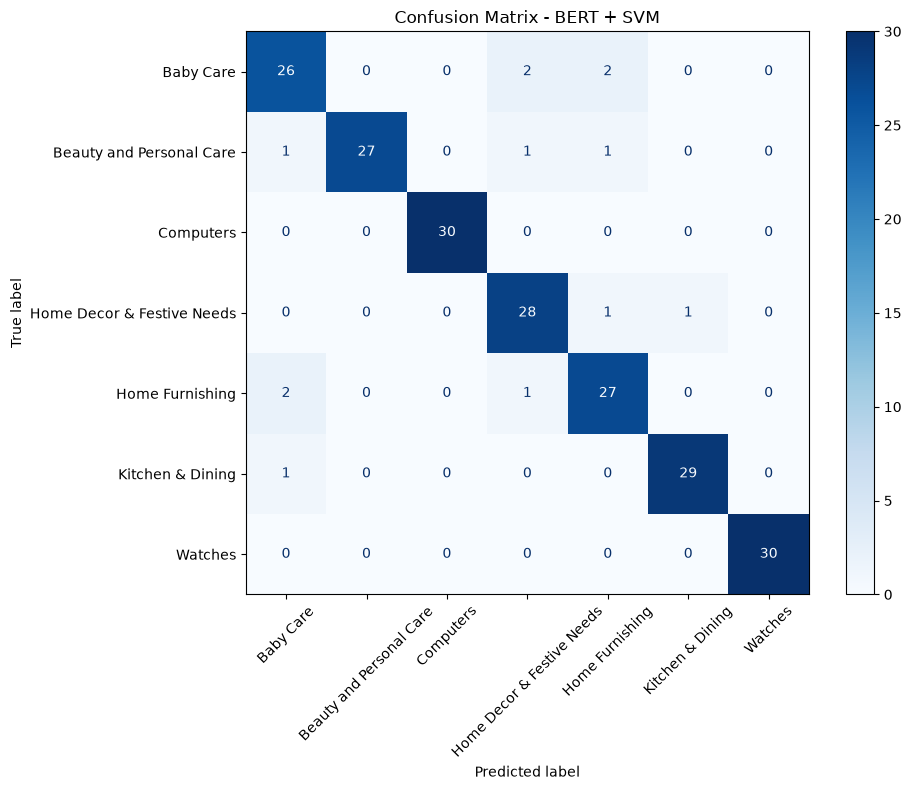

In [38]:
y_pred_bert = grid_search_bert.predict(X_test_bert)
print(f"Standard BERT + SVM\nAccuracy: {accuracy_score(y_test, y_pred_bert):.4f}\nclassification report:\n{classification_report(y_test, y_pred_bert, target_names=target_names)}")

cm = confusion_matrix(y_test, y_pred_bert)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - BERT + SVM")
plt.tight_layout()
plt.show()

# TF-IDF

As a classical baseline, text is vectorized with TF-IDF (top 5000 terms) and reduced to 384 dimensions via Truncated SVD, so its feature size matches the SBERT embeddings used elsewhere in the notebook. An SVM is grid-searched on the reduced training features and scored on the validation set.

In [39]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

In [40]:
svd = TruncatedSVD(n_components=384, random_state=42)
X_train_tfidf_reduced = svd.fit_transform(X_train_tfidf)
X_test_tfidf_reduced = svd.transform(X_test_tfidf)

In [41]:
X_test_tfidf_reduced.shape

(210, 384)

In [42]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tfidf_svm = LinearSVC(random_state=42, max_iter=20000, class_weight='balanced')
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'loss': ['hinge', 'squared_hinge']
}

grid_search_tfidf = GridSearchCV(
    estimator=tfidf_svm, 
    param_grid=param_grid, 
    cv=inner_cv, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=0
)

nested_scores_svm = cross_val_score(
    grid_search_tfidf, 
    X_train_tfidf_reduced, 
    y_train, 
    cv=outer_cv, 
    scoring='accuracy', 
    n_jobs=-1
)

In [43]:
print(f"SVM Nested CV Accuracy: {nested_scores_svm.mean():.3f} with StD {nested_scores_svm.std():.3f}")

SVM Nested CV Accuracy: 0.919 with StD 0.015


In [44]:
grid_search_tfidf.fit(X_train_tfidf_reduced, y_train)

/home/bright381/OpenClassrooms/Projet_8/SBERT-TFIDF/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/bright381/OpenClassrooms/Projet_8/SBERT-TFIDF/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'loss': ['hinge', 'squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [45]:
print(f"Biais d'optimisme: {grid_search_tfidf.best_score_ - nested_scores_svm.mean():.3f} (Score interne: {grid_search_tfidf.best_score_:.3f} vs score attendu: {nested_scores_svm.mean():.3f})")

Biais d'optimisme: 0.013 (Score interne: 0.932 vs score attendu: 0.919)


TF-IDF + SVM
Accuracy: 0.9333
classification report:                            precision    recall  f1-score   support

                 Baby Care       0.88      0.77      0.82        30
  Beauty and Personal Care       0.93      0.93      0.93        30
                 Computers       1.00      1.00      1.00        30
Home Decor & Festive Needs       0.93      0.93      0.93        30
           Home Furnishing       0.83      0.97      0.89        30
          Kitchen & Dining       0.97      0.93      0.95        30
                   Watches       1.00      1.00      1.00        30

                  accuracy                           0.93       210
                 macro avg       0.94      0.93      0.93       210
              weighted avg       0.94      0.93      0.93       210



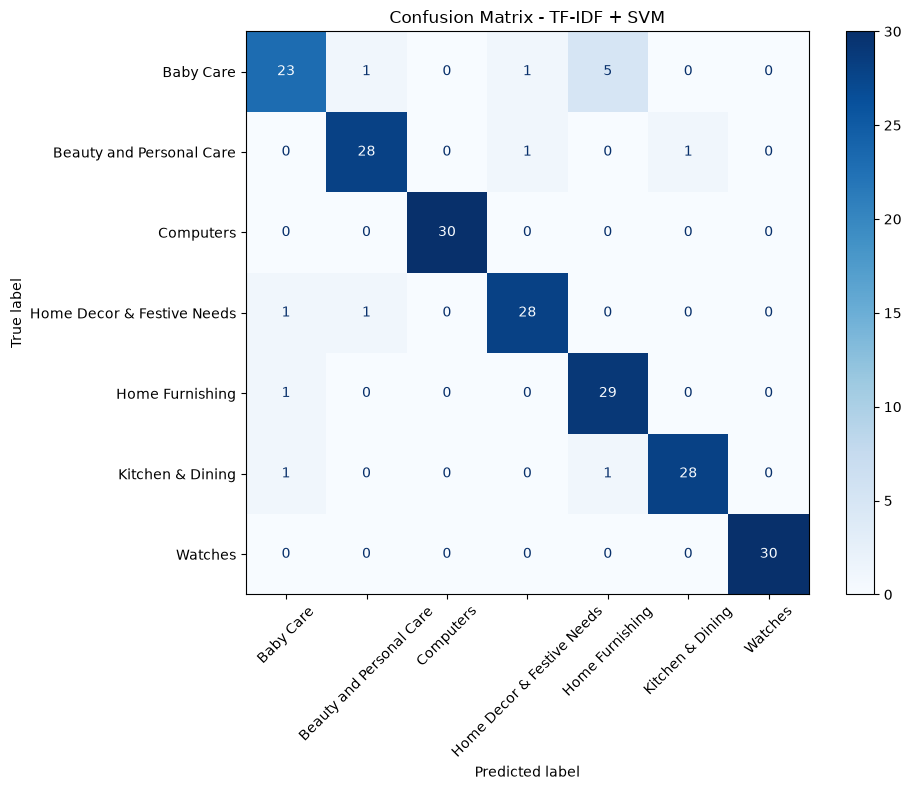

In [46]:
y_pred_tfidf = grid_search_tfidf.predict(X_test_tfidf_reduced)
print(f"TF-IDF + SVM\nAccuracy: {accuracy_score(y_test, y_pred_tfidf):.4f}\nclassification report:{classification_report(y_test, y_pred_tfidf, target_names=target_names)}")

cm = confusion_matrix(y_test, y_pred_tfidf)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - TF-IDF + SVM")
plt.tight_layout()
plt.show()

# SBERT

SBERT (`all-MiniLM-L6-v2`) produces a sentence embedding directly, without BERT's manual pooling step. We encode train/val/test text, grid-search an SVM on the training embeddings, and score it on the validation set.

In [47]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_sbert = sbert_model.encode(X_train_raw, show_progress_bar=True)
X_test_sbert = sbert_model.encode(X_test_raw, show_progress_bar=True)

Batches: 100%|██████████| 7/7 [00:01<00:00,  5.87it/s]


In [48]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sbert_svm = LinearSVC(random_state=42, max_iter=20000, class_weight='balanced')
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'loss': ['hinge', 'squared_hinge']
}

grid_search_sbert = GridSearchCV(
    estimator=sbert_svm, 
    param_grid=param_grid, 
    cv=inner_cv, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=0
)

nested_scores_svm = cross_val_score(
    grid_search_sbert, 
    X_train_sbert, 
    y_train, 
    cv=outer_cv, 
    scoring='accuracy', 
    n_jobs=-1
)

In [49]:
print(f"SVM Nested CV Accuracy: {nested_scores_svm.mean():.3f} with StD {nested_scores_svm.std():.3f}")

SVM Nested CV Accuracy: 0.939 with StD 0.012


In [50]:
grid_search_sbert.fit(X_train_sbert, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'loss': ['hinge', 'squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [51]:
print(f"Biais d'optimisme: {grid_search_sbert.best_score_ - nested_scores_svm.mean():.3f} (Score interne: {grid_search_sbert.best_score_:.3f} vs score attendu: {nested_scores_svm.mean():.3f})")

Biais d'optimisme: 0.004 (Score interne: 0.943 vs score attendu: 0.939)


SBERT + SVM
Accuracy: 0.9286
classification report:                            precision    recall  f1-score   support

                 Baby Care       0.82      0.77      0.79        30
  Beauty and Personal Care       0.97      0.93      0.95        30
                 Computers       0.97      1.00      0.98        30
Home Decor & Festive Needs       0.90      0.90      0.90        30
           Home Furnishing       0.84      0.90      0.87        30
          Kitchen & Dining       1.00      1.00      1.00        30
                   Watches       1.00      1.00      1.00        30

                  accuracy                           0.93       210
                 macro avg       0.93      0.93      0.93       210
              weighted avg       0.93      0.93      0.93       210



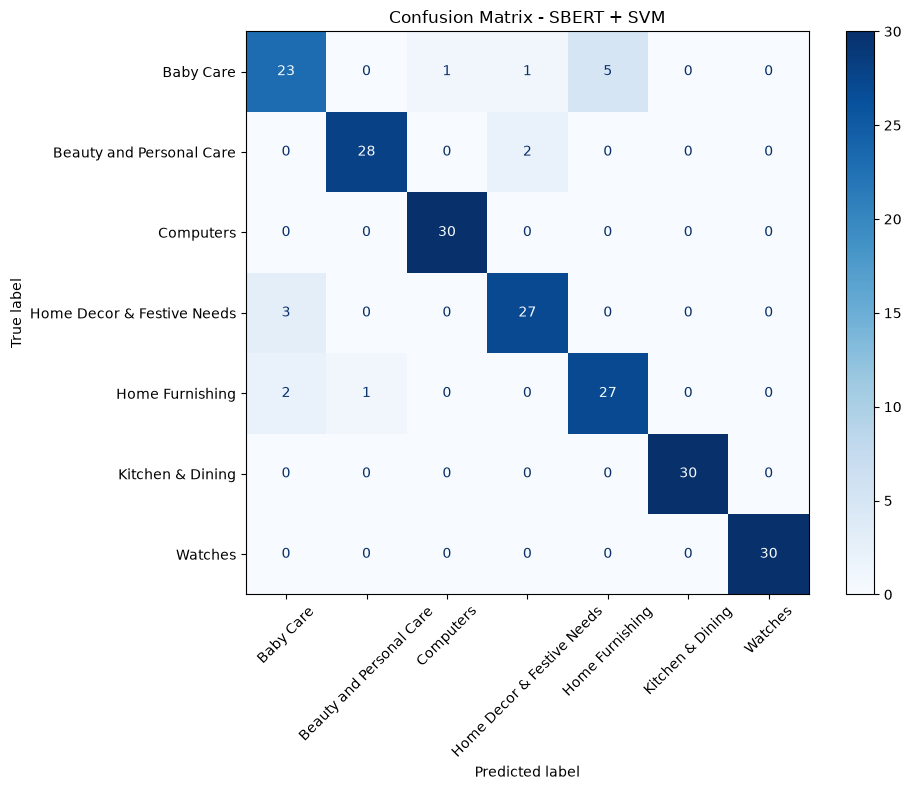

In [52]:
y_pred_sbert = grid_search_sbert.predict(X_test_sbert)
print(f"SBERT + SVM\nAccuracy: {accuracy_score(y_test, y_pred_sbert):.4f}\nclassification report:{classification_report(y_test, y_pred_sbert, target_names=target_names)}")

cm = confusion_matrix(y_test, y_pred_sbert)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - SBERT + SVM")
plt.tight_layout()
plt.show()

# SBERT and TF-IDF features

This section builds a **hybrid representation** for each document by combining its SBERT embedding with its (dimensionality-reduced) TF-IDF vector. The two are weighted so the semantic SBERT signal dominates while TF-IDF still contributes lexical/keyword information. We compare an SVM and a small neural network (FCNN) trained on these hybrid features, both scored on the validation set.

## load sbert and encode

Re-encode train/val/test text with SBERT (kept separate from the earlier standalone SBERT section so this section can run independently).

In [53]:
sbert_model.eval()

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

In [54]:
X_train_sbert = sbert_model.encode(X_train_raw, convert_to_numpy=True, show_progress_bar=True)
X_test_sbert = sbert_model.encode(X_test_raw, convert_to_numpy=True, show_progress_bar=True)

Batches: 100%|██████████| 7/7 [00:01<00:00,  5.87it/s]


## tf-idf and dimension reduction

Re-vectorize the text with TF-IDF and reduce it to 384 components, matching the SBERT embedding size so the two can be combined below.

In [55]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

In [56]:
svd = TruncatedSVD(n_components=384, random_state=42)
X_train_tfidf_reduced = svd.fit_transform(X_train_tfidf)
X_test_tfidf_reduced = svd.transform(X_test_tfidf)

## SVM training

Combine the SBERT and TF-IDF features into a single hybrid vector using a weighted sum (`sbert_weight=0.9`, `tfidf_weight=0.1`), then grid-search an SVM on the training set and evaluate it on the validation set.

In [57]:
sbert_weight=0.9
tfidf_weight=0.1

In [58]:
X_train_hybrid = X_train_tfidf_reduced*tfidf_weight + X_train_sbert*sbert_weight
X_test_hybrid = X_test_tfidf_reduced*tfidf_weight + X_test_sbert*sbert_weight

In [59]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hybrid_svm = LinearSVC(random_state=42, max_iter=20000, class_weight='balanced')
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'loss': ['hinge', 'squared_hinge']
}

grid_search_hybrid_svm = GridSearchCV(
    estimator=hybrid_svm, 
    param_grid=param_grid, 
    cv=inner_cv, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=0
)

nested_scores_svm = cross_val_score(
    grid_search_hybrid_svm, 
    X_train_hybrid, 
    y_train, 
    cv=outer_cv, 
    scoring='accuracy', 
    n_jobs=-1
)

In [60]:
print(f"SVM Nested CV Accuracy: {nested_scores_svm.mean():.3f} with StD {nested_scores_svm.std():.3f}")

SVM Nested CV Accuracy: 0.938 with StD 0.006


In [61]:
grid_search_hybrid_svm.fit(X_train_hybrid, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(cla...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'loss': ['hinge', 'squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Co

In [62]:
print(f"Biais d'optimisme: {grid_search_hybrid_svm.best_score_ - nested_scores_svm.mean():.3f} (Score interne: {grid_search_hybrid_svm.best_score_:.3f} vs score attendu: {nested_scores_svm.mean():.3f})")

Biais d'optimisme: -0.001 (Score interne: 0.937 vs score attendu: 0.938)


## results


=== RESULTS ===
Accuracy: 0.9333

Classification Report:
                            precision    recall  f1-score   support

                 Baby Care      0.828     0.800     0.814        30
  Beauty and Personal Care      0.966     0.933     0.949        30
                 Computers      0.968     1.000     0.984        30
Home Decor & Festive Needs      0.900     0.900     0.900        30
           Home Furnishing      0.871     0.900     0.885        30
          Kitchen & Dining      1.000     1.000     1.000        30
                   Watches      1.000     1.000     1.000        30

                  accuracy                          0.933       210
                 macro avg      0.933     0.933     0.933       210
              weighted avg      0.933     0.933     0.933       210



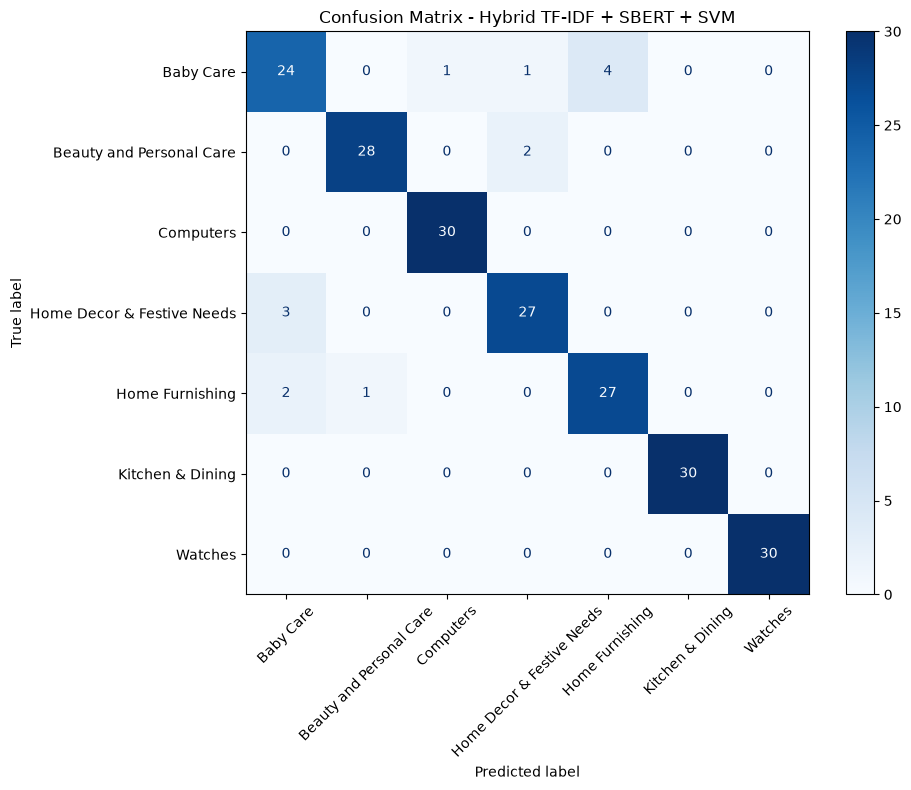

In [63]:
y_pred = grid_search_hybrid_svm.predict(X_test_hybrid)

print("\n=== RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Hybrid TF-IDF + SBERT + SVM")
plt.tight_layout()
plt.show()

# SBERT TFIDF + FCNN

Instead of an SVM, we train a small fully-connected neural network (FCNN) on the same hybrid SBERT+TF-IDF features, monitoring on the validation set during training and scoring it there afterwards.

In [64]:
def create_model(learning_rate=1e-3, dropout_rate=0.3):
    model = Sequential([
        Input(shape=(X_train_hybrid.shape[1],)),
        Dense(256, activation='relu'),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(7, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [65]:
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

clf = KerasClassifier(
    model=create_model, 
    verbose=0,
    callbacks=[early_stop],
    validation_split=0.2,
    epochs=100
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', clf)
])

param_grid = {
    'clf__model__learning_rate': [1e-3, 5e-4, 4e-4, 2e-4, 1e-4],
    'clf__model__dropout_rate': [0.2, 0.25, 0.3, 0.35, 0.4],
    'clf__batch_size': [64]
}

grid_search_fcnn = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    n_jobs=2,
    verbose=0
)

print("Nested CV...")
nested_scores_fcnn = cross_val_score(
    grid_search_fcnn, 
    X_train_hybrid, 
    y_train, 
    cv=outer_cv, 
    scoring='accuracy',
    n_jobs=2
)
print(f"FCNN Nested CV Accuracy: {nested_scores_fcnn.mean():.3f} with StD {nested_scores_fcnn.std():.3f}")

Nested CV...


I0000 00:00:1787324033.770074  923930 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787324033.770074  923931 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787324033.794461  923930 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787324033.794461  923931 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to

FCNN Nested CV Accuracy: 0.936 with StD 0.013


In [66]:
grid_search_fcnn.fit(X_train_hybrid, y_train)

I0000 00:00:1787324339.125142 2058084 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787324339.149068 2058084 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787324339.782081 2058084 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787324339.782241 2058084 cudart_stub.cc:31] Could not find cuda drivers on your machine, 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__batch_size': [64], 'clf__model__dropout_rate': [0.2, 0.25, ...], 'clf__model__learning_rate': [0.001, 0.0005, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for cal

In [67]:
print(f"Meilleurs hyperparamètres: {grid_search_fcnn.best_params_}")
print(f"Biais d'optimisme: {grid_search_fcnn.best_score_ - nested_scores_fcnn.mean():.3f} "
      f"(Score interne optimiste: {grid_search_fcnn.best_score_:.3f} vs score attendu: {nested_scores_fcnn.mean():.3f})")

Meilleurs hyperparamètres: {'clf__batch_size': 64, 'clf__model__dropout_rate': 0.3, 'clf__model__learning_rate': 0.0002}
Biais d'optimisme: -0.011 (Score interne optimiste: 0.925 vs score attendu: 0.936)



=== RESULTS ===
Accuracy: 0.9286

Classification Report:
                            precision    recall  f1-score   support

                 Baby Care      0.867     0.867     0.867        30
  Beauty and Personal Care      0.933     0.933     0.933        30
                 Computers      0.968     1.000     0.984        30
Home Decor & Festive Needs      0.871     0.900     0.885        30
           Home Furnishing      0.897     0.867     0.881        30
          Kitchen & Dining      0.966     0.933     0.949        30
                   Watches      1.000     1.000     1.000        30

                  accuracy                          0.929       210
                 macro avg      0.929     0.929     0.928       210
              weighted avg      0.929     0.929     0.928       210



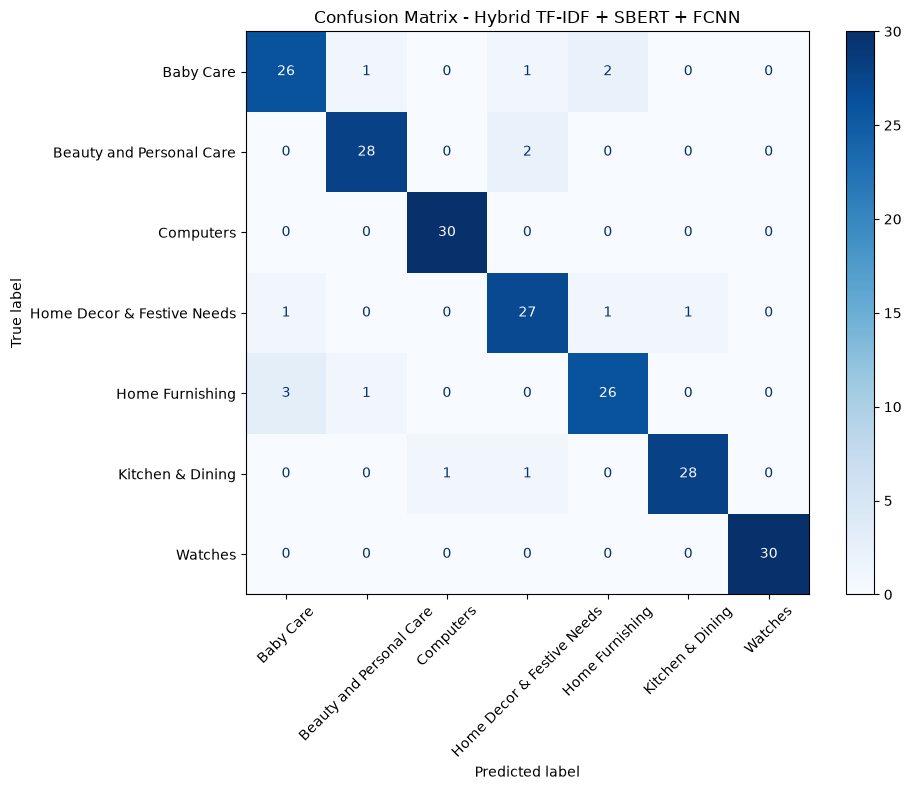

In [68]:
y_pred = grid_search_fcnn.predict(X_test_hybrid)

print("\n=== RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix - Hybrid TF-IDF + SBERT + FCNN")
plt.tight_layout()
plt.show()

# Final test evaluation

Finally, we gather every tuned model from the sections above, compare their accuracy on the validation set to pick a single winner, and evaluate that one model — and only that one — on the held-out test set, giving an unbiased estimate of real-world performance.

In [69]:
def get_predictions(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return np.argmax(estimator.predict_proba(X), axis=1)
    preds = estimator.predict(X)
    return np.argmax(preds, axis=1) if preds.ndim > 1 else preds

# Define models with all feature sets
models = {
    "BERT + SVM": (grid_search_bert, X_train_bert, X_test_bert),
    "TF-IDF + SVM": (grid_search_tfidf, X_train_tfidf_reduced, X_test_tfidf_reduced),
    "SBERT + SVM": (grid_search_sbert, X_train_sbert, X_test_sbert),
    "Hybrid TF-IDF + SBERT + SVM": (grid_search_hybrid_svm, X_train_hybrid, X_test_hybrid),
    "Hybrid TF-IDF + SBERT + FCNN": (grid_search_fcnn, X_train_hybrid, X_test_hybrid)
}

# Compute accuracies on train and test sets
results = {}
for name, (estimator, X_train_m, X_test_m) in models.items():
    y_pred_train = get_predictions(estimator, X_train_m)
    y_pred_test = get_predictions(estimator, X_test_m)
    
    results[name] = {
        'Train': accuracy_score(y_train, y_pred_train),
        'Test': accuracy_score(y_test, y_pred_test)
    }

# Create results DataFrame
results_df = pd.DataFrame(results).T
print("Model Accuracies across Train and Test Sets:")
print(results_df.round(4))

best_model_name = results_df['Test'].idxmax()
print(f"\nBest model on test set: {best_model_name} (Accuracy: {results_df.loc[best_model_name, 'Test']:.4f})")

Model Accuracies across Train and Test Sets:
                               Train    Test
BERT + SVM                    1.0000  0.9381
TF-IDF + SVM                  0.9798  0.9333
SBERT + SVM                   0.9917  0.9286
Hybrid TF-IDF + SBERT + SVM   0.9893  0.9333
Hybrid TF-IDF + SBERT + FCNN  0.9893  0.9286

Best model on test set: BERT + SVM (Accuracy: 0.9381)


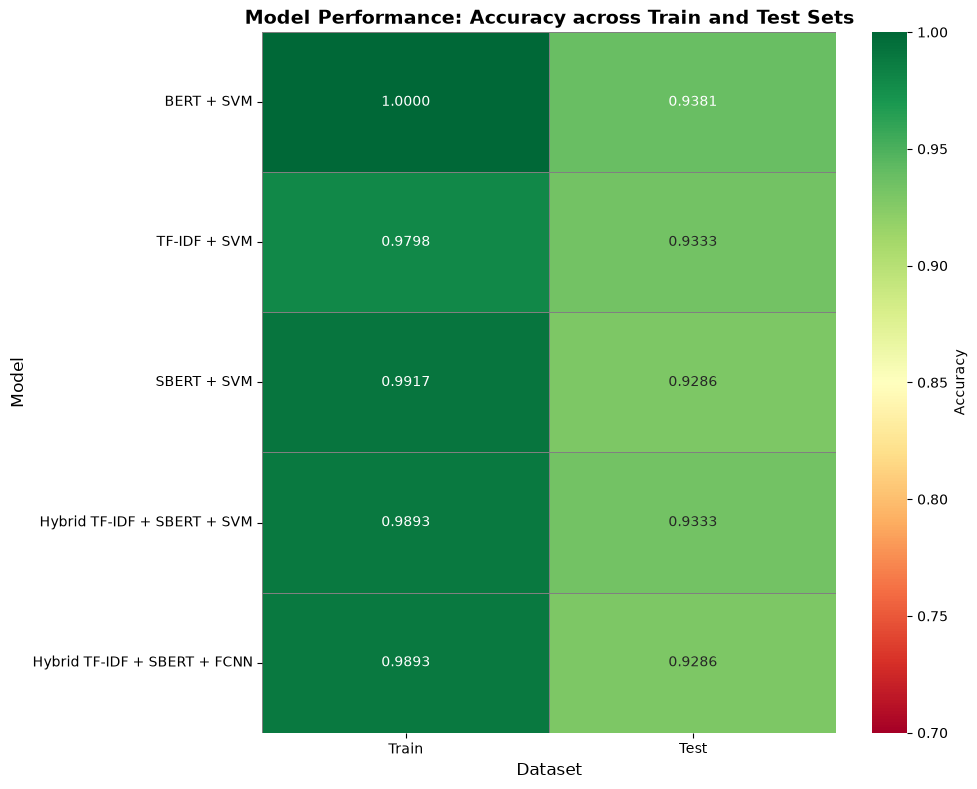

In [70]:
# Create heatmap visualization
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(results_df, annot=True, fmt='.4f', cmap='RdYlGn', 
            cbar_kws={'label': 'Accuracy'}, vmin=0.7, vmax=1.0,
            linewidths=0.5, linecolor='gray', ax=ax)
plt.title('Model Performance: Accuracy across Train and Test Sets', fontsize=14, fontweight='bold')
plt.xlabel('Dataset', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()